In [7]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports successful!')

Imports successful!


In [8]:
RAVDESS_DIR = '../data/archive'

files = glob.glob(os.path.join(RAVDESS_DIR, '**', '*.wav'), recursive=True)
labels_raw = [os.path.basename(f).split('-')[2] for f in files]

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

labels = [EMOTION_MAP[l] for l in labels_raw]

print(f'Total files: {len(files)}')
print(f'\nEmotion Distribution:')
print(pd.Series(labels).value_counts())

Total files: 2880

Emotion Distribution:
angry        384
fearful      384
disgust      384
sad          384
surprised    384
happy        384
calm         384
neutral      192
Name: count, dtype: int64


In [9]:
def extract_features(filepath, sr=22050, duration=3.0):
    y, sr = librosa.load(filepath, sr=sr, duration=duration)

    # MFCCs — captures vocal tract shape
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_feat = np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])

    # Chroma — captures pitch patterns
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_feat = np.hstack([chroma.mean(axis=1), chroma.std(axis=1)])

    # Spectral Centroid — captures brightness of voice
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    centroid_feat = np.array([centroid.mean(), centroid.std()])

    # Zero-Crossing Rate — captures roughness of voice
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_feat = np.array([zcr.mean(), zcr.std()])

    # RMS Energy — captures loudness
    rms = librosa.feature.rms(y=y)
    rms_feat = np.array([rms.mean(), rms.std()])

    # Spectral Rolloff — captures energy concentration
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_feat = np.array([rolloff.mean(), rolloff.std()])

    return np.hstack([mfcc_feat, chroma_feat, centroid_feat, zcr_feat, rms_feat, rolloff_feat])

# Test on one file
test_feats = extract_features(files[0])
print(f'Feature vector shape: {test_feats.shape}')
print(f'First 5 values: {test_feats[:5].round(3)}')

Feature vector shape: (112,)
First 5 values: [-488.46    42.618   -6.084    3.053  -13.423]


In [10]:
X = []
y = []

for i, (filepath, label) in enumerate(zip(files, labels)):
    if i % 200 == 0:
        print(f'Processing {i}/{len(files)}...')
    feats = extract_features(filepath)
    X.append(feats)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(f'Done. X shape: {X.shape}, y shape: {y.shape}')

np.save('../data/X_features.npy', X)
np.save('../data/y_labels.npy', y)
print('Features saved to data folder.')

Processing 0/2880...
Processing 200/2880...
Processing 400/2880...
Processing 600/2880...
Processing 800/2880...
Processing 1000/2880...
Processing 1200/2880...
Processing 1400/2880...
Processing 1600/2880...
Processing 1800/2880...
Processing 2000/2880...
Processing 2200/2880...
Processing 2400/2880...
Processing 2600/2880...
Processing 2800/2880...
Done. X shape: (2880, 112), y shape: (2880,)
Features saved to data folder.


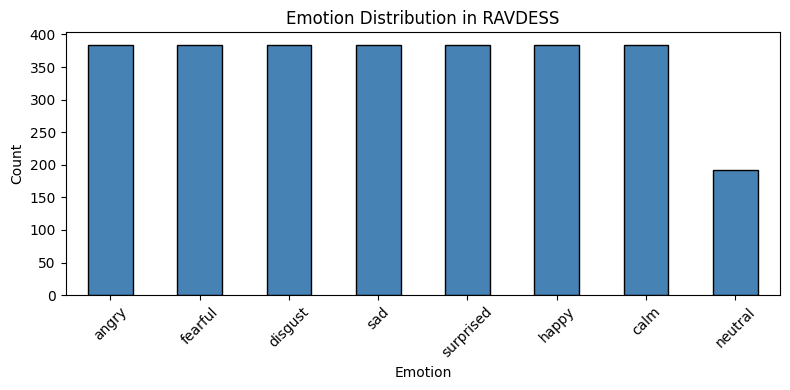

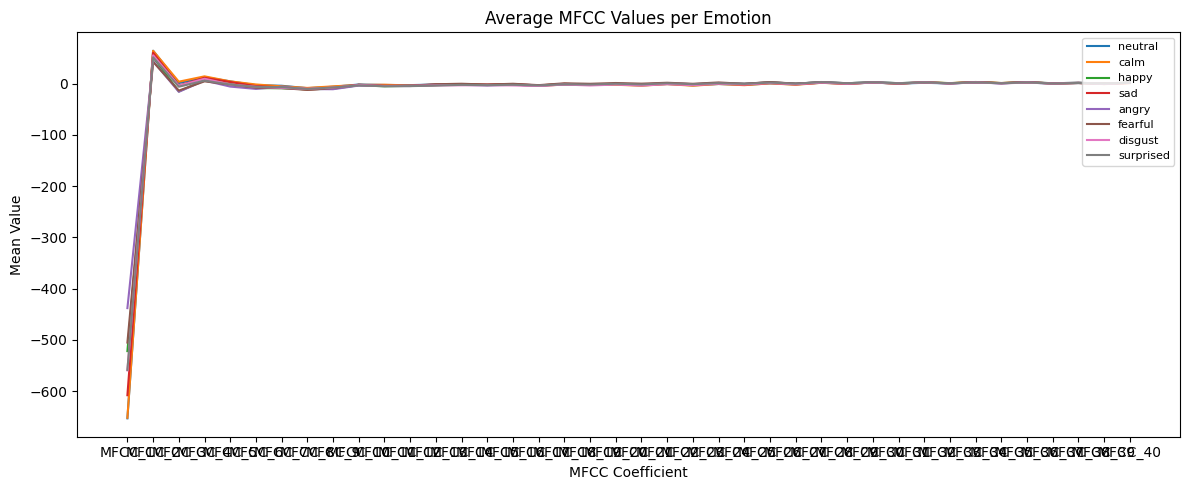

Feature extraction complete. Files saved:
  - ../data/X_features.npy
  - ../data/y_labels.npy


In [11]:
# Plot emotion distribution
plt.figure(figsize=(8, 4))
pd.Series(y).value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Emotion Distribution in RAVDESS')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot average MFCC values per emotion
df_feat = pd.DataFrame(X[:, :40], columns=[f'MFCC_{i+1}' for i in range(40)])
df_feat['emotion'] = y

plt.figure(figsize=(12, 5))
for emotion in EMOTION_MAP.values():
    subset = df_feat[df_feat['emotion'] == emotion]
    plt.plot(subset.iloc[:, :40].mean(), label=emotion)
plt.title('Average MFCC Values per Emotion')
plt.xlabel('MFCC Coefficient')
plt.ylabel('Mean Value')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print('Feature extraction complete. Files saved:')
print('  - ../data/X_features.npy')
print('  - ../data/y_labels.npy')